In [2]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
train = pd.read_csv(r"C:\Users\Lenovo\Downloads\Customer Churn Prediction\customer_churn_dataset-training-master.csv")

In [5]:
train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [6]:
train.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0
440832,449999.0,31.0,Male,48.0,20.0,1.0,14.0,Premium,Quarterly,567.77,21.0,0.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [8]:
train.shape

(440833, 12)

In [9]:
train.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [10]:
train.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [11]:
train.duplicated().sum()

np.int64(0)

In [12]:
train['Gender'].value_counts()

Gender
Male      250252
Female    190580
Name: count, dtype: int64

In [13]:
train['Subscription Type'].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [14]:
train['Contract Length'].value_counts()


Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [15]:
train['Churn'].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [16]:
train.drop("CustomerID", axis=1, inplace=True)

In [17]:
train.corr(numeric_only=True)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


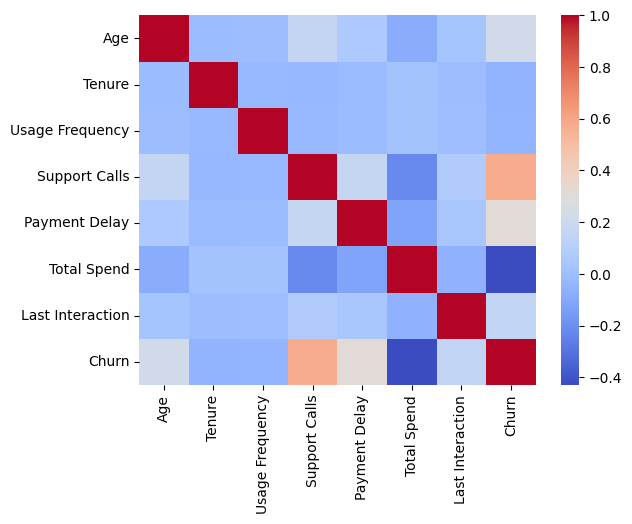

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(train.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [19]:
train.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
Name: Churn, dtype: float64

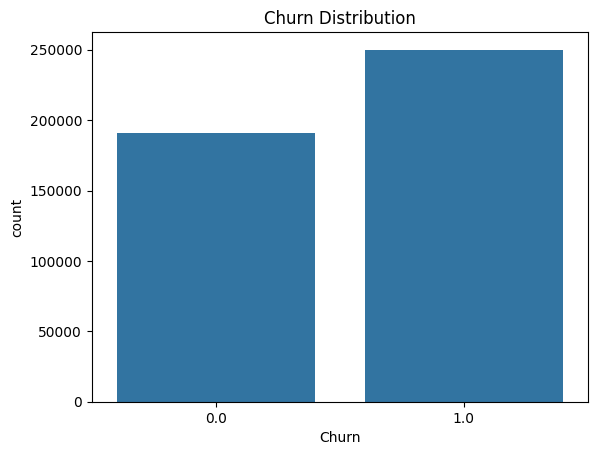

In [20]:
sns.countplot(x='Churn', data=train)
plt.title("Churn Distribution")
plt.show()

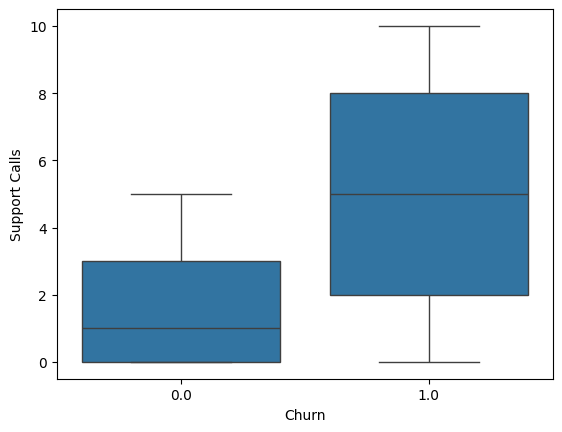

In [21]:
sns.boxplot(x='Churn', y='Support Calls', data=train)
plt.show()

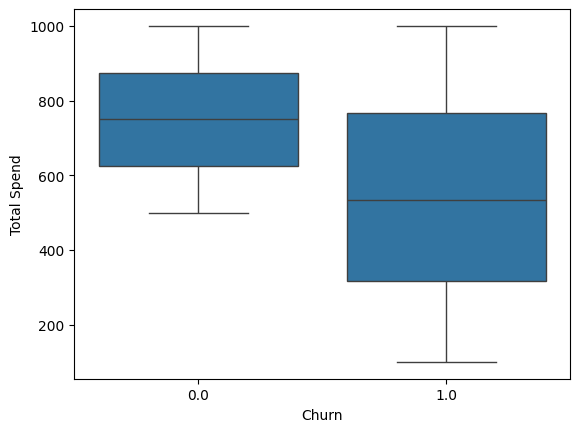

In [22]:
sns.boxplot(x='Churn', y='Total Spend', data=train)
plt.show()

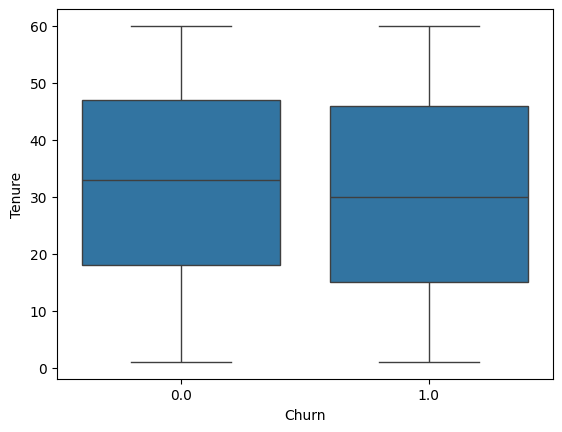

In [23]:
sns.boxplot(x='Churn', y='Tenure', data=train)
plt.show()

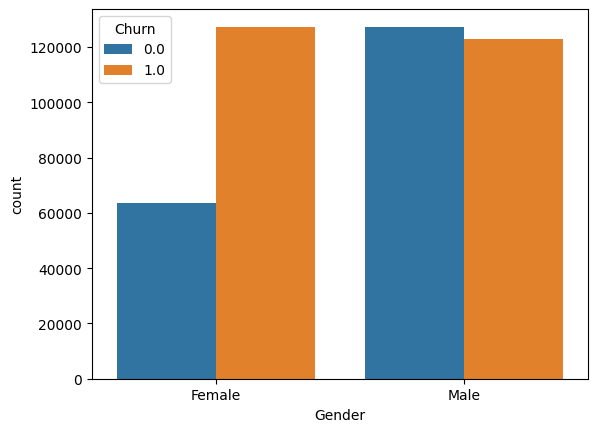

In [24]:
sns.countplot(x='Gender', hue='Churn', data=train)
plt.show()

#MARKER FILE

<Axes: xlabel='Subscription Type', ylabel='count'>

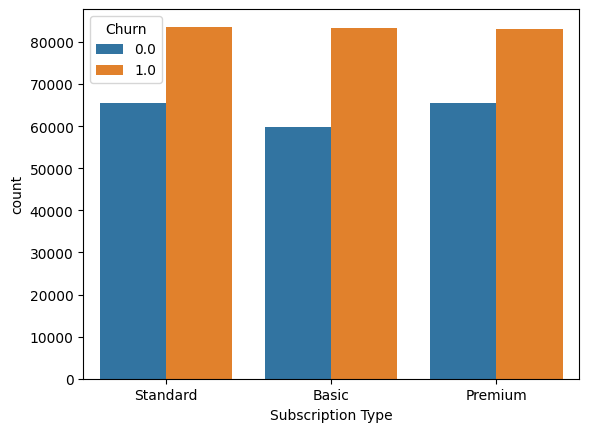

In [25]:
sns.countplot(x='Subscription Type', hue='Churn', data=train)

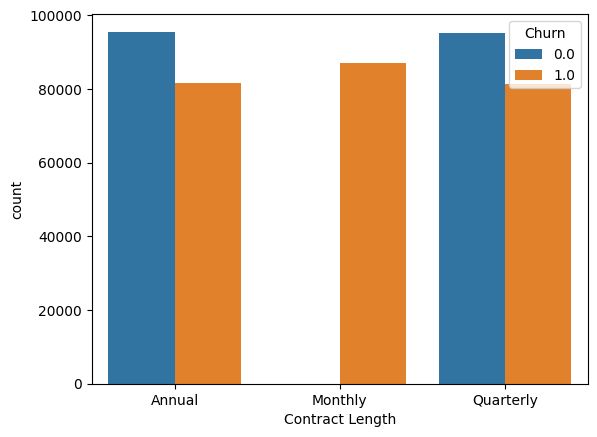

In [26]:
sns.countplot(x='Contract Length', hue='Churn', data=train)
plt.show()

In [27]:
num_cols = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend']

for col in num_cols:
    train[col].fillna(train[col].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7608\2480765454.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7608\2480765454.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [28]:
cat_cols = ['Gender','Subscription Type','Contract Length']

for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7608\2375044559.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)


In [29]:
train['Churn'].fillna(train['Churn'].mode()[0], inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7608\3801332646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Churn'].fillna(train['Churn'].mode()[0], inplace=True)


In [30]:
train['Last Interaction'] = pd.to_datetime(train['Last Interaction'], errors='coerce')

train['Last_Days'] = (train['Last Interaction'].max() - train['Last Interaction']).dt.days

train.drop("Last Interaction", axis=1, inplace=True)

In [31]:
train['Last_Days'].fillna(train['Last_Days'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7608\3499557545.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Last_Days'].fillna(train['Last_Days'].median(), inplace=True)


In [32]:
train.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Churn                0
Last_Days            0
dtype: int64

In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440833 non-null  float64
 1   Gender             440833 non-null  object 
 2   Tenure             440833 non-null  float64
 3   Usage Frequency    440833 non-null  float64
 4   Support Calls      440833 non-null  float64
 5   Payment Delay      440833 non-null  float64
 6   Subscription Type  440833 non-null  object 
 7   Contract Length    440833 non-null  object 
 8   Total Spend        440833 non-null  float64
 9   Churn              440833 non-null  float64
 10  Last_Days          440833 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


In [34]:
train['Gender'] = train['Gender'].map({'Male':1, 'Female':0})

In [35]:
train = pd.get_dummies(train, columns=['Subscription Type','Contract Length'], drop_first=True)

In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Age                         440833 non-null  float64
 1   Gender                      440833 non-null  int64  
 2   Tenure                      440833 non-null  float64
 3   Usage Frequency             440833 non-null  float64
 4   Support Calls               440833 non-null  float64
 5   Payment Delay               440833 non-null  float64
 6   Total Spend                 440833 non-null  float64
 7   Churn                       440833 non-null  float64
 8   Last_Days                   440833 non-null  float64
 9   Subscription Type_Premium   440833 non-null  bool   
 10  Subscription Type_Standard  440833 non-null  bool   
 11  Contract Length_Monthly     440833 non-null  bool   
 12  Contract Length_Quarterly   440833 non-null  bool   
dtypes: bool(4), fl

In [37]:
bool_cols = train.select_dtypes(include='bool').columns
train[bool_cols] = train[bool_cols].astype(int)

In [38]:
train['Gender'].unique()

array([0, 1])

In [39]:
X = train.drop("Churn", axis=1)
y = train["Churn"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
"""from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)"""

LogisticRegression(max_iter=1000)

In [45]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9908128891762223

Confusion Matrix:
 [[38141     2]
 [  808 49216]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     38143
         1.0       1.00      0.98      0.99     50024

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167



In [48]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.9999829867353246
Test Accuracy: 0.9908128891762223


In [49]:


importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

print(feat_imp)

Support Calls                 0.314909
Total Spend                   0.221421
Age                           0.148452
Payment Delay                 0.137023
Contract Length_Monthly       0.131223
Tenure                        0.017205
Gender                        0.010201
Usage Frequency               0.009623
Contract Length_Quarterly     0.006724
Subscription Type_Standard    0.001648
Subscription Type_Premium     0.001571
Last_Days                     0.000000
dtype: float64


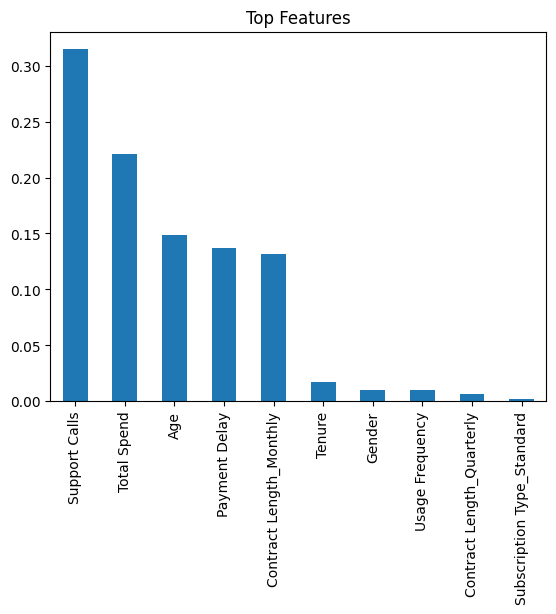

In [50]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())

Scores: [0.99114181 0.99126657 0.99141402 0.9913005  0.9913799 ]
Average Accuracy: 0.9913005607095589
